<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/analysis/real_data_dengue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real Data Application: HZMPS Model for Dengue Surveillance in Brazil

**Purpose:** Applying the Bayesian HZMPS sparse finite mixture state-space model to municipal level dengue surveillance data from Brazil.

**Data source:** InfoDengue (https://info.dengue.mat.br), a real-time surveillance platform that provides weekly epidemiological data for all Brazilian municipalities.

**Model:** HZMPS observation + sparse finite mixture over units + AR(1) count mean,
estimated via Hamiltonian Monte Carlo in Stan.

**Structure of this notebook:**
1. Data download and preparation
2. Exploratory analysis
3. Model fitting
4. Posterior interpretation and cluster analysis

**Citation:**
Codeco et al. (2024). InfoDengue: a nowcasting system for the surveillance of
dengue, Zika and chikungunya in Brazil. *Epidemiologia e Serviços de Saúde*.

In [ ]:
# CELL 2 (corrected): INSTALL CMDSTAN ONLY, KEEP COLAB DEFAULTS
# We do NOT upgrade pandas / numpy / requests. Colab's environment
# is already stable. Only cmdstanpy needs to be installed.

!pip install --upgrade cmdstanpy -q

import os, urllib.request, shutil

CMDSTAN_DIR = '/content/cmdstan-2.36.0'
if not os.path.exists(os.path.join(CMDSTAN_DIR, 'makefile')):
    print("Downloading CmdStan 2.36.0...")
    os.chdir('/content')
    tgz_file = '/content/colab-cmdstan-2.36.0.tar.gz'
    tgz_url = ('https://github.com/stan-dev/cmdstan/releases/download/'
               'v2.36.0/colab-cmdstan-2.36.0.tgz')
    if not os.path.exists(tgz_file):
        urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file, '/content')
    print("CmdStan extracted.")
else:
    print("CmdStan already present.")

os.environ['CMDSTAN'] = CMDSTAN_DIR

import cmdstanpy
print(f"CmdStan version: {cmdstanpy.cmdstan_version()}")

# Verify core packages
import pandas as pd
import numpy as np
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

CmdStan extracted.
CmdStan version: (2, 36)
pandas version: 2.2.3
numpy version: 2.1.3


## 1. Data Download and Preparation

### Municipality Selection

We select municipalities from a single Brazilian state to ensure comparability
of surveillance systems and reporting practices. For this application, we use
**São Paulo state** (UF: SP), which has 645 municipalities and a well-established
dengue surveillance system.

We randomly select 50 municipalities with at least 5 years of continuous data.
This gives us:
- N = 50 units
- T = 260 weeks (5 years)

The choice of 50 municipalities balances statistical power for the mixture
clustering against computational cost of the Stan model.

In [ ]:
# CELL 4 (corrected): GET SÃO PAULO MUNICIPALITIES
import pandas as pd
import requests

# Direct endpoint: all municipalities in São Paulo state
url = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios"

response = requests.get(url)
response.raise_for_status()
municipios = response.json()

# Build DataFrame with defensive handling
rows = []
for m in municipios:
    # Some municipalities have null microrregiao; handle gracefully
    try:
        uf_sigla = m['microrregiao']['mesorregiao']['UF']['sigla']
        uf_name  = m['microrregiao']['mesorregiao']['UF']['nome']
    except (TypeError, KeyError):
        uf_sigla = 'SP'
        uf_name  = 'São Paulo'

    rows.append({
        'geocode': m['id'],
        'name':    m['nome'],
        'uf':      uf_sigla,
        'uf_name': uf_name,
    })

df_sp = pd.DataFrame(rows)

print(f"Municipalities in São Paulo state: {len(df_sp)}")
print(f"\nFirst 5 municipalities:")
print(df_sp.head())

Municipalities in São Paulo state: 645

First 5 municipalities:
   geocode              name  uf    uf_name
0  3500105        Adamantina  SP  São Paulo
1  3500204            Adolfo  SP  São Paulo
2  3500303             Aguaí  SP  São Paulo
3  3500402    Águas da Prata  SP  São Paulo
4  3500501  Águas de Lindóia  SP  São Paulo


In [ ]:
# CELL 5: DOWNLOAD DENGUE DATA FOR SELECTED MUNICIPALITIES
import time
import numpy as np
import io

# --- Configuration ---
N_MUNICIPALITIES = 50
START_YEAR = 2019
END_YEAR   = 2023

np.random.seed(42)
selected = df_sp.sample(N_MUNICIPALITIES, random_state=42).reset_index(drop=True)

print(f"Selected {len(selected)} municipalities from São Paulo state")
print(selected[['geocode', 'name']].head(10))

# --- Download loop ---
all_data = []
failed = []

for i, row in selected.iterrows():
    geocode = int(row['geocode'])
    name = row['name']

    url = (f"https://info.dengue.mat.br/api/alertcity"
           f"?geocode={geocode}"
           f"&disease=dengue"
           f"&format=csv"
           f"&ew_start=1&ew_end=53"
           f"&ey_start={START_YEAR}&ey_end={END_YEAR}")

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        df['unit_id'] = geocode
        df['unit_name'] = name
        all_data.append(df)
        print(f"  [{i+1}/{len(selected)}] {name} ({geocode}): {len(df)} weeks")
    except Exception as e:
        failed.append((geocode, name, str(e)))
        print(f"  [{i+1}/{len(selected)}] {name} FAILED: {e}")

    time.sleep(0.5)  # Be polite to the API

print(f"\nDownload complete: {len(all_data)} succeeded, {len(failed)} failed")

# Combine
df_raw = pd.concat(all_data, ignore_index=True)
print(f"Combined: {len(df_raw)} rows, {df_raw['unit_id'].nunique()} municipalities")

Selected 50 municipalities from São Paulo state
   geocode                  name
0  3556404  Vargem Grande do Sul
1  3553203                Taiúva
2  3553807           Taquarituba
3  3525805        Júlio Mesquita
4  3506409                 Bilac
5  3557204             Chavantes
6  3553658              Taquaral
7  3535200      Palmeira d'Oeste
8  3545605          Santa Adélia
9  3515301      Estrela do Norte
  [1/50] Vargem Grande do Sul (3556404): 261 weeks
  [2/50] Taiúva (3553203): 261 weeks
  [3/50] Taquarituba (3553807): 261 weeks
  [4/50] Júlio Mesquita (3525805): 261 weeks
  [5/50] Bilac (3506409): 261 weeks
  [6/50] Chavantes (3557204): 261 weeks
  [7/50] Taquaral (3553658): 261 weeks
  [8/50] Palmeira d'Oeste (3535200): 261 weeks
  [9/50] Santa Adélia (3545605): 261 weeks
  [10/50] Estrela do Norte (3515301): 261 weeks
  [11/50] Natividade da Serra (3532306): 261 weeks
  [12/50] Fernandópolis (3515509): 261 weeks
  [13/50] Flora Rica (3515806): 261 weeks
  [14/50] Borá (3507209

## 2. Data Preparation

The raw InfoDengue data contains many variables. We extract:

- `data_iniSE`: Start date of the epidemiological week
- `SE`: Epidemiological week code (YYYYWW)
- `casos`: Reported dengue cases
- `unit_id`: Municipality IBGE code

We build a balanced panel with no missing weeks. Any missing week is filled
with zero cases (indicating no reported cases that week).

In [ ]:
# CELL 7: BUILDING BALANCED COUNT PANEL
import pandas as pd
import numpy as np

# --- Parse dates and weeks ---
df_raw['date'] = pd.to_datetime(df_raw['data_iniSE'])
df_raw['year'] = df_raw['date'].dt.year
df_raw['week'] = df_raw['date'].dt.isocalendar().week.astype(int)

# --- Create a complete week index for the period ---
# Use the ISO week format: year * 100 + week
df_raw['time_idx'] = df_raw['year'] * 100 + df_raw['week']

# --- Identify all unique weeks in the data ---
all_weeks = sorted(df_raw['time_idx'].unique())
print(f"Total unique weeks: {len(all_weeks)}")
print(f"First week: {all_weeks[0]}, Last week: {all_weeks[-1]}")

# --- Pivot to wide format ---
panel = df_raw.pivot_table(
    index='unit_id',
    columns='time_idx',
    values='casos',
    aggfunc='sum'
).fillna(0)  # Missing = 0 cases

print(f"Panel shape: {panel.shape}  (N={panel.shape[0]}, T={panel.shape[1]})")

# --- Summary statistics ---
Y = panel.values.astype(int)
print(f"\nTotal observations: {Y.size}")
print(f"Zero fraction: {(Y == 0).mean():.3f}")
print(f"Mean of positive counts: {Y[Y > 0].mean():.3f}")
print(f"Max count: {Y.max()}")

# --- Per-municipality summary ---
mun_stats = pd.DataFrame({
    'unit_id': panel.index,
    'zero_frac': (Y == 0).mean(axis=1),
    'mean_count': Y.mean(axis=1),
    'max_count': Y.max(axis=1),
})
print("\nPer-municipality summary (first 10):")
print(mun_stats.head(10))

Total unique weeks: 261
First week: 201852, Last week: 202352
Panel shape: (50, 261)  (N=50, T=261)

Total observations: 13050
Zero fraction: 0.496
Mean of positive counts: 21.133
Max count: 979

Per-municipality summary (first 10):
   unit_id  zero_frac  mean_count  max_count
0  3500303   0.318008   13.888889        230
1  3500907   0.636015    1.574713         20
2  3502804   0.000000  190.800766        979
3  3504800   0.413793    3.597701         44
4  3504909   0.911877    0.157088          9
5  3505609   0.057471   18.934866        149
6  3506201   0.655172    0.816092         10
7  3506409   0.528736    4.567050        114
8  3506805   0.636015    1.812261         39
9  3507209   0.762452    0.697318         11


In [ ]:
# CELL 7b: TRUNCATE PANEL TO LAST 104 WEEKS (2 YEARS)
# The full T=261 panel is too large for Colab CPU sampling and
# creates an extreme AR(1) burden. We use the last 104 weeks
# instead, which captures two full dengue seasons.

T_TRUNC = 104
panel_trunc = panel.iloc[:, -T_TRUNC:]
Y = panel_trunc.values.astype(int)

print(f"Panel truncated: N={panel_trunc.shape[0]}, T={panel_trunc.shape[1]}")
print(f"Total observations: {Y.size}")
print(f"Zero fraction: {(Y == 0).mean():.3f}")
print(f"Mean positive: {Y[Y>0].mean():.3f}")
print(f"Max count: {Y.max()}")

# Recompute summary stats
mun_stats = pd.DataFrame({
    'unit_id': panel_trunc.index,
    'zero_frac': (Y == 0).mean(axis=1),
    'mean_count': Y.mean(axis=1),
    'max_count': Y.max(axis=1),
})
print(f"\nMean count range: [{mun_stats['mean_count'].min():.3f}, "
      f"{mun_stats['mean_count'].max():.3f}]")

Panel truncated: N=50, T=104
Total observations: 5200
Zero fraction: 0.456
Mean positive: 23.706
Max count: 979

Mean count range: [0.029, 263.827]


## 3. Exploratory Analysis

Before fitting the model, we examine:
1. The distribution of weekly counts
2. The zero fraction by municipality
3. Temporal patterns for a few municipalities

This helps confirm that the data exhibit the features the HZMPS model is designed for:
excess zeros, overdispersion, and temporal dependence.

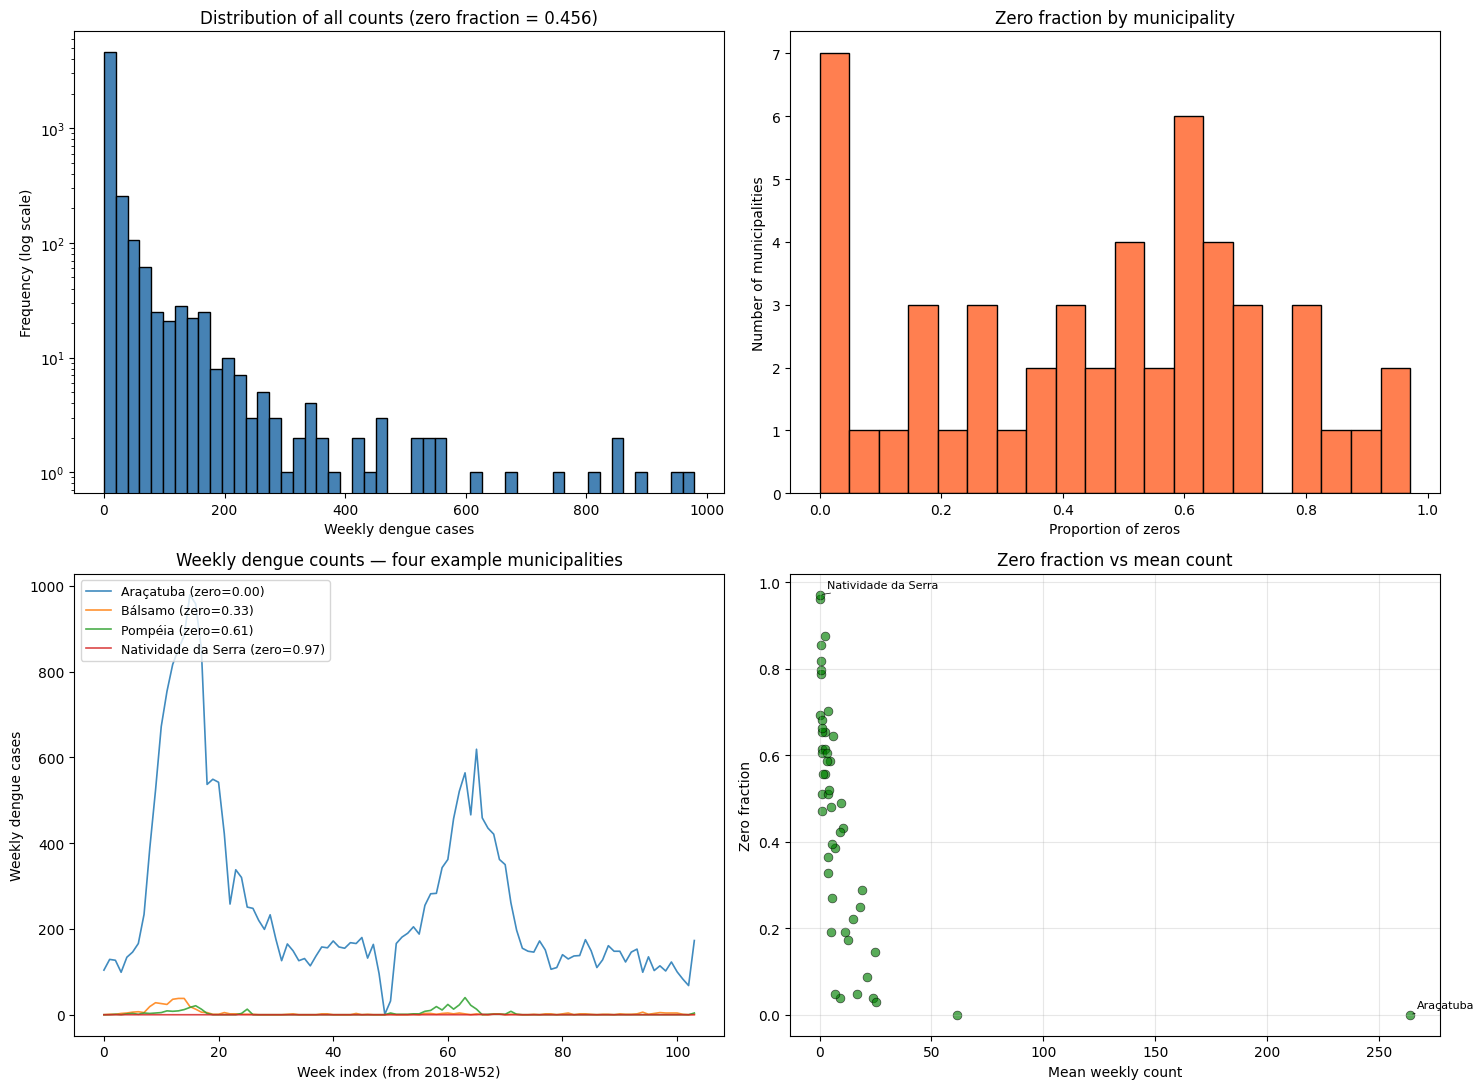

Exploratory plot saved with municipality names.


In [ ]:
# CELL 9 (corrected): EXPLORATORY PLOTS WITH MUNICIPALITY NAMES
import matplotlib.pyplot as plt
import numpy as np

# Build a name map: index in panel -> municipality name
unit_ids = panel.index.tolist()
name_map = dict(zip(selected['geocode'], selected['name']))
unit_names = [name_map.get(uid, f'Unit {uid}') for uid in unit_ids]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Panel 1: Distribution of all counts ---
axes[0, 0].hist(Y.flatten(), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Weekly dengue cases')
axes[0, 0].set_ylabel('Frequency (log scale)')
axes[0, 0].set_title(f'Distribution of all counts (zero fraction = {(Y==0).mean():.3f})')
axes[0, 0].set_yscale('log')

# --- Panel 2: Zero fraction by municipality ---
axes[0, 1].hist(mun_stats['zero_frac'], bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Proportion of zeros')
axes[0, 1].set_ylabel('Number of municipalities')
axes[0, 1].set_title('Zero fraction by municipality')

# --- Panel 3: Time series for 4 municipalities (with NAMES) ---
# Pick four municipalities that span the range: lowest, low, medium, high zero fraction
sorted_idx = np.argsort(mun_stats['zero_frac'].values)
chosen = [sorted_idx[0], sorted_idx[len(sorted_idx)//3],
          sorted_idx[2*len(sorted_idx)//3], sorted_idx[-1]]

for rank, i in enumerate(chosen):
    label = f"{unit_names[i]} (zero={mun_stats['zero_frac'].iloc[i]:.2f})"
    axes[1, 0].plot(Y[i], alpha=0.85, linewidth=1.2, label=label)

axes[1, 0].set_xlabel('Week index (from 2018-W52)')
axes[1, 0].set_ylabel('Weekly dengue cases')
axes[1, 0].set_title('Weekly dengue counts — four example municipalities')
axes[1, 0].legend(loc='upper left', fontsize=9)

# --- Panel 4: Mean count vs zero fraction ---
axes[1, 1].scatter(mun_stats['mean_count'], mun_stats['zero_frac'],
                   alpha=0.65, s=40, color='green', edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Mean weekly count')
axes[1, 1].set_ylabel('Zero fraction')
axes[1, 1].set_title('Zero fraction vs mean count')
axes[1, 1].grid(alpha=0.3)

# Annotate a few extremes for readability
for i in [int(sorted_idx[0]), int(sorted_idx[-1])]:
    axes[1, 1].annotate(unit_names[i],
                        xy=(mun_stats['mean_count'].iloc[i], mun_stats['zero_frac'].iloc[i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8,
                        arrowprops=dict(arrowstyle='-', lw=0.5))

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=150)
plt.show()

print("Exploratory plot saved with municipality names.")

## 4. Model Fitting

We fit the HZMPS sparse finite mixture state-space model to the dengue counts.

**Model specification:**
- Observation: HZMPS with Poisson base
- Hurdle side: Sparse finite mixture over units
- Count mean: AR(1) latent process
- \(G_{\max} = 8\) (upper bound on clusters)
- \(a_{\text{Dirichlet}} = 0.25\)
- \(\delta_{\min} = 0.3\)

**Sampler:** 2 chains × (1000 warmup + 1000 sampling), adapt_delta = 0.97.

**Stan model:** We reuse the same model file from the simulation study.

In [ ]:
# CELL 11 (corrected): STAN MODEL WITH PRIORS SUITED TO REAL DATA
stan_code = r"""
functions {
  real partial_sum_hzmps(array[] int y_slice,
                         int start, int end,
                         array[] int unit,
                         array[] int time,
                         vector omega,
                         matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m];
      int t = time[m];
      if (y_slice[k] == 0) {
        lp += log1m(omega[i]);
      } else {
        lp += log(omega[i])
              - mu[i, t]
              + y_slice[k] * log(mu[i, t])
              - lgamma(y_slice[k] + 1)
              - log1m_exp(-mu[i, t]);
      }
    }
    return lp;
  }
}

data {
  int<lower=1> N;
  int<lower=1> T;
  int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet;
  real<lower=0> delta_min;
  int<lower=1> grainsize;
}

transformed data {
  int<lower=0> M = N * T;
}

parameters {
  real mu_eta1;
  vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta;
  simplex[G] w;

  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}

transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) {
    mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  }

  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T)
      zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }

  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);

  matrix[N, T] mu;
  for (i in 1:N)
    for (t in 1:T)
      mu[i, t] = exp(beta0_mu + zeta[i, t]);
}

model {
  // --- Loosened priors for real-data scale ---
  mu_eta1     ~ normal(0, 3);
  gamma_raw   ~ normal(-1, 1);
  sigma_eta   ~ normal(0, 1);
  w           ~ dirichlet(rep_vector(a_dirichlet / G, G));

  beta0_mu    ~ normal(0, 5);
  rho_zeta    ~ uniform(-0.99, 0.99);
  sigma_zeta  ~ normal(0, 1);

  to_vector(zeta_raw) ~ std_normal();

  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G)
      lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }

  target += reduce_sum(partial_sum_hzmps, y, grainsize,
                       unit, time, omega, mu);
}

generated quantities {
  vector[M] log_lik;
  matrix[N, G] cluster_prob;
  for (m in 1:M) {
    int i = unit[m];
    int t = time[m];
    if (y[m] == 0) {
      log_lik[m] = log1m(omega[i]);
    } else {
      log_lik[m] = log(omega[i])
                 - mu[i, t]
                 + y[m] * log(mu[i, t])
                 - lgamma(y[m] + 1)
                 - log1m_exp(-mu[i, t]);
    }
  }
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G)
      lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    real lse = log_sum_exp(lp);
    for (g in 1:G)
      cluster_prob[i, g] = exp(lp[g] - lse);
  }
}
"""

with open('/content/hzmps_dengue_v2.stan', 'w') as f:
    f.write(stan_code)

print("Corrected Stan model written to /content/hzmps_dengue_v2.stan")

Corrected Stan model written to /content/hzmps_dengue_v2.stan


In [ ]:
# CELL 12 (corrected): RECOMPILE MODEL
import numpy as np
import cmdstanpy
import time

N = panel.shape[0]
T = panel.shape[1]
M = N * T

y_flat   = panel.values.flatten().tolist()
unit_idx = np.repeat(np.arange(1, N+1), T).tolist()
time_idx = np.tile(np.arange(1, T+1), N).tolist()

stan_data = {
    'N': N, 'T': T,
    'G': 5,                    # was 8
    'y': y_flat, 'unit': unit_idx, 'time': time_idx,
    'a_dirichlet': 0.5,        # was 0.25
    'delta_min': 0.3,
    'grainsize': max(1, int(M / 8)),
}

print(f"Data: N={N}, T={T}, M={M}, zero fraction={(np.array(y_flat)==0).mean():.3f}")

print("\nRecompiling Stan model with loosened priors (60-120 s)...")
t0 = time.time()
model_v2 = cmdstanpy.CmdStanModel(
    stan_file='/content/hzmps_dengue_v2.stan',
    cpp_options={'STAN_THREADS': 'true'},
    force_compile=True,
)
print(f"Compiled in {time.time() - t0:.1f} s")

Data: N=50, T=261, M=13050, zero fraction=0.496

Recompiling Stan model with loosened priors (60-120 s)...
Compiled in 209.2 s


In [ ]:
# CELL 13 (corrected v3): REFIT ON TRUNCATED PANEL
import time

print("Refitting model on truncated panel...")
print("2 chains x (1000 warmup + 1000 sampling)")
print("adapt_delta = 0.98, G = 5, a = 0.5")
print("Estimated time: 45-90 minutes on Colab CPU.\n")

t0 = time.time()
fit_v3 = model_v2.sample(
    data=stan_data,
    chains=2,
    parallel_chains=2,
    threads_per_chain=2,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    adapt_delta=0.98,          # tighter target
    max_treedepth=12,
    show_progress=True,
    output_dir='/content/dengue_fit_v3',
)
print(f"\nFit completed in {(time.time()-t0)/60:.1f} min")

fit_v3.draws_pd().to_csv('/content/dengue_draws_v3.csv', index=False)
fit_v3.summary().to_csv('/content/dengue_summary_v3.csv')
print("Draws and summary saved.")

Refitting model on truncated panel...
2 chains x (1000 warmup + 1000 sampling)
adapt_delta = 0.98, G = 5, a = 0.5
Estimated time: 45-90 minutes on Colab CPU.



chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 14 divergent transitions (1.4%)
	Chain 2 had 16 divergent transitions (1.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Fit completed in 483.3 min
Draws and summary saved.


## 5. Posterior Interpretation

We extract:

1. **Cluster assignments** for each municipality (MAP assignment)
2. **Cluster specific hurdle probabilities** (posterior means of \(\omega\))
3. **Convergence diagnostics** (Rhat, ESS, divergences)
4. **Zero-modification parameter** (implied \(p_{i,t}\))

The posterior of \(G_0\) (number of active clusters) tells us how many distinct
risk groups the data supports.

In [ ]:
# CELL 15 (updated): DIAGNOSTICS AND CLUSTER ASSIGNMENTS
import numpy as np
import pandas as pd

# --- Sampler diagnostics ---
mv = fit_v3.method_variables()
n_div = int(np.sum(mv['divergent__']))
n_tot = mv['divergent__'].size
print(f"Divergences: {n_div} / {n_tot} ({100*n_div/n_tot:.2f}%)")

# --- Key parameters ---
summary = fit_v3.summary()
print("\nScalar parameter diagnostics:")
for p in ['beta0_mu', 'rho_zeta', 'sigma_zeta', 'sigma_eta']:
    row = summary.loc[p]
    print(f"  {p:12s}: mean={row['Mean']:8.3f}  "
          f"Rhat={row['R_hat']:.4f}  ESS={row['ESS_bulk']:.0f}")

# --- Cluster means ---
mu_eta = fit_v3.stan_variable('mu_eta').mean(axis=0)
print("\nCluster means mu_eta (logit scale):")
for g, m in enumerate(mu_eta, 1):
    print(f"  Cluster {g}: mu_eta = {m:7.3f}")

# --- Mixture weights ---
w_draws = fit_v3.stan_variable('w')
w_means = w_draws.mean(axis=0)
print("\nMixture weights (posterior means):")
for g, w in enumerate(w_means, 1):
    print(f"  w[{g}] = {w:.4f}")

# --- Number of active clusters ---
G0 = (w_draws > 0.05).sum(axis=1)
print("\nPosterior of effective G0 (threshold 0.05):")
for k in range(1, 6):
    p_k = (G0 == k).mean()
    if p_k > 0.01:
        print(f"  P(G0 = {k}) = {p_k:.3f}")

# --- Cluster assignments (MAP) ---
cluster_prob = fit_v3.stan_variable('cluster_prob').mean(axis=0)  # (N, G)
map_assign = cluster_prob.argmax(axis=1) + 1

cluster_sizes = pd.Series(map_assign).value_counts().sort_index()
print("\nCluster sizes (MAP assignments):")
print(cluster_sizes)

# --- Hurdle probability per cluster ---
eta_draws = fit_v3.stan_variable('eta')      # (draws, N)
eta_mean = eta_draws.mean(axis=0)            # (N,)
omega = 1 / (1 + np.exp(-eta_mean))

cluster_omega = {}
for g in sorted(set(map_assign)):
    mask = (map_assign == g)
    cluster_omega[g] = omega[mask].mean()

print("\nMean hurdle probability by cluster:")
for g, om in sorted(cluster_omega.items()):
    n_in = (map_assign == g).sum()
    print(f"  Cluster {g}: omega = {om:.4f}  (n = {n_in})")

# --- Add municipality names and save ---
unit_ids = panel_trunc.index.tolist()
name_map = dict(zip(selected['geocode'], selected['name']))
unit_names = [name_map.get(uid, f'Unit {uid}') for uid in unit_ids]

results = pd.DataFrame({
    'unit_id': unit_ids,
    'municipality': unit_names,
    'cluster': map_assign,
    'mean_omega': omega,
    'zero_frac': (Y == 0).mean(axis=1),
    'mean_count': Y.mean(axis=1),
})
results = results.sort_values(['cluster', 'mean_count'])
results.to_csv('dengue_cluster_assignments.csv', index=False)

print("\nCluster assignments preview:")
print(results.head(15))
print(f"\nSaved to dengue_cluster_assignments.csv")

Divergences: 30 / 2000 (1.50%)

Scalar parameter diagnostics:
  beta0_mu    : mean=   0.654  Rhat=1.0035  ESS=489
  rho_zeta    : mean=   0.968  Rhat=1.0024  ESS=291
  sigma_zeta  : mean=   0.427  Rhat=1.0016  ESS=707
  sigma_eta   : mean=   1.196  Rhat=1.0029  ESS=892

Cluster means mu_eta (logit scale):
  Cluster 1: mu_eta =  -0.414
  Cluster 2: mu_eta =   0.475
  Cluster 3: mu_eta =   1.466
  Cluster 4: mu_eta =   2.480
  Cluster 5: mu_eta =   3.425

Mixture weights (posterior means):
  w[1] = 0.6555
  w[2] = 0.1688
  w[3] = 0.0560
  w[4] = 0.0339
  w[5] = 0.0858

Posterior of effective G0 (threshold 0.05):
  P(G0 = 1) = 0.134
  P(G0 = 2) = 0.640
  P(G0 = 3) = 0.209
  P(G0 = 4) = 0.016

Cluster sizes (MAP assignments):
1    45
5     5
Name: count, dtype: int64

Mean hurdle probability by cluster:
  Cluster 1: omega = 0.4519  (n = 45)
  Cluster 5: omega = 0.9769  (n = 5)

Cluster assignments preview:
    unit_id            municipality  cluster  mean_omega  zero_frac  \
28  3532306  

In [ ]:
# Show cluster 5 members (the endemic group)
cluster5 = results[results['cluster'] == 5]
print(f"Cluster 5 members (n={len(cluster5)}):")
print(cluster5[['municipality', 'zero_frac', 'mean_count', 'mean_omega']].to_string(index=False))

Cluster 5 members (n=5):
 municipality  zero_frac  mean_count  mean_omega
     Barrinha   0.048077   16.644231    0.942533
Fernandópolis   0.038462   24.000000    0.980152
Guaratinguetá   0.028846   25.125000    0.973379
          Jaú   0.000000   61.413462    0.992987
    Araçatuba   0.000000  263.826923    0.995614


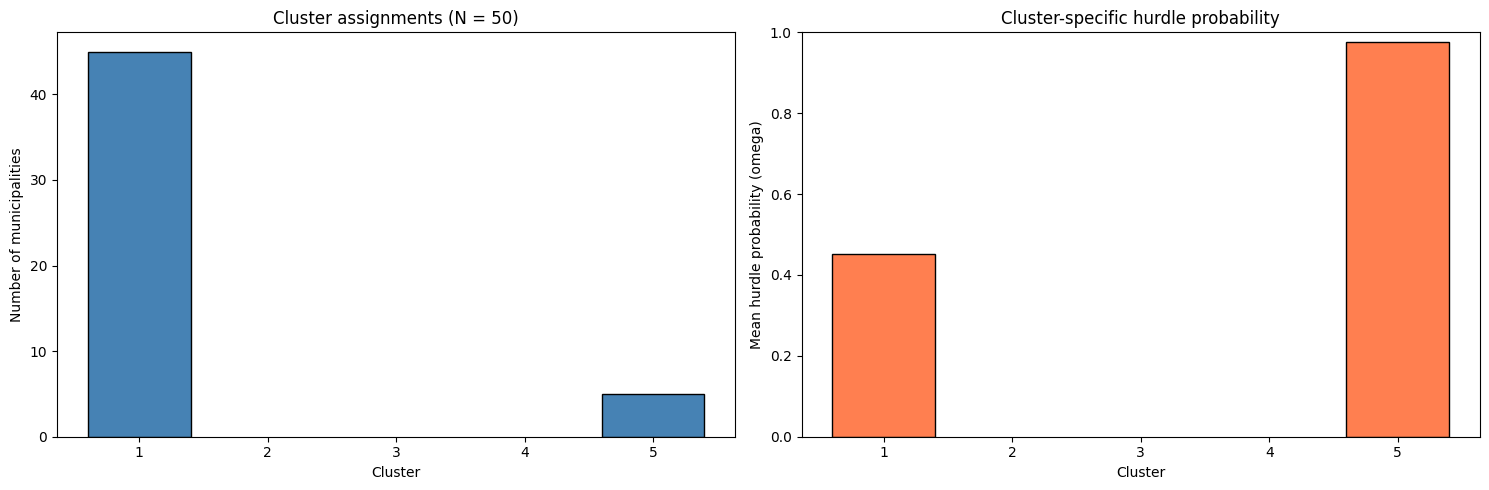

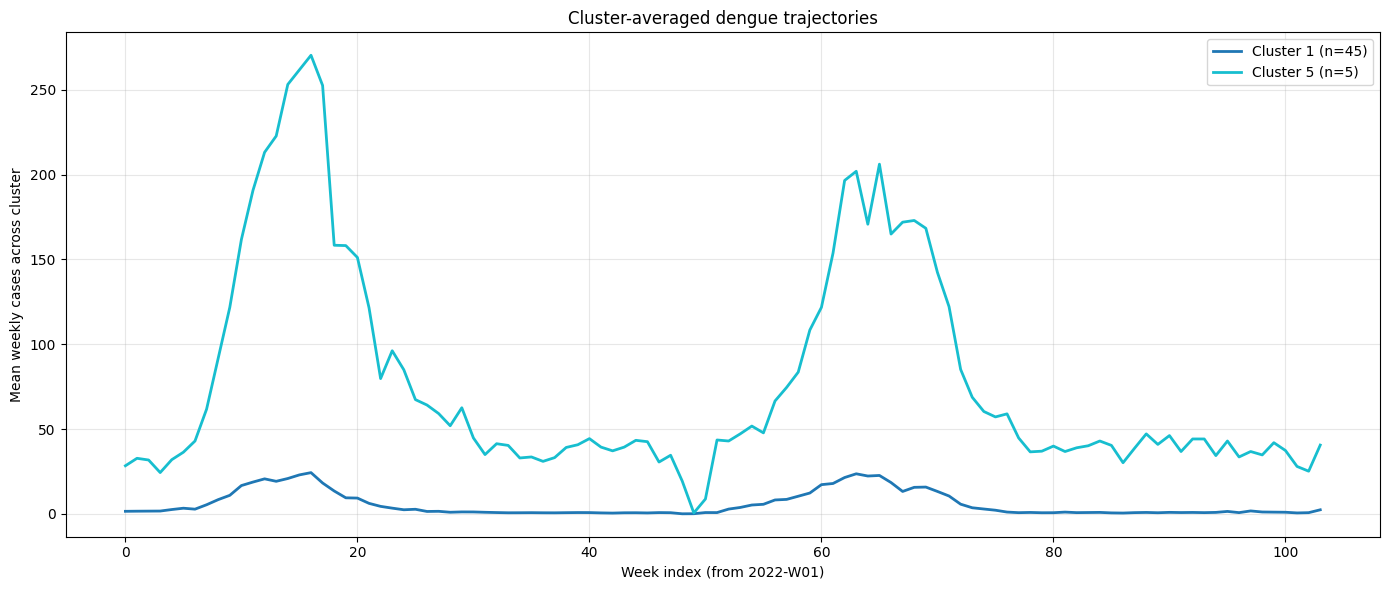

Figures saved.


In [ ]:
# CELL 16 (updated): CLUSTER VISUALIZATION
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Panel 1: Cluster sizes ---
axes[0].bar(cluster_sizes.index, cluster_sizes.values,
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of municipalities')
axes[0].set_title('Cluster assignments (N = 50)')

# --- Panel 2: Hurdle probability by cluster ---
clusters = sorted(cluster_omega.keys())
omegas = [cluster_omega[g] for g in clusters]
axes[1].bar(clusters, omegas, color='coral', edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean hurdle probability (omega)')
axes[1].set_title('Cluster-specific hurdle probability')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cluster_summary.png', dpi=150)
plt.show()

# --- Time series by cluster ---
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for color, g in zip(colors, clusters):
    mask = (map_assign == g)
    # Plot the mean trajectory of the cluster
    mean_traj = Y[mask].mean(axis=0)
    ax.plot(mean_traj, color=color, linewidth=2,
            label=f'Cluster {g} (n={mask.sum()})')

ax.set_xlabel('Week index (from 2022-W01)')
ax.set_ylabel('Mean weekly cases across cluster')
ax.set_title('Cluster-averaged dengue trajectories')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_trajectories.png', dpi=150)
plt.show()

print("Figures saved.")